# Mason Miller and Adrián Morejón: Two Historic Relief Seasons

Every reliever season since 2016 with 0 starts and 60+ IP (855 seasons; 510 since 2021 for Stuff+ and Pitching+), 2026 through Sept. 24.

Run top to bottom from this folder. The code lives in the `.py` files next to this notebook. Savant's 2026 leaderboards change daily, so each Savant pull only runs when its CSV is missing (pass `refresh=True` to pull again).

In [1]:
import pandas as pd
from IPython.display import Image, display

import ranks, savant, fastball, charts

pd.set_option("display.width", 250, "display.max_columns", 40, "display.max_colwidth", 60, "display.max_rows", 200)

## 1. FanGraphs ranks among all 855 reliever seasons

Six FanGraphs tabs (Standard, Advanced, Statcast, Win Probability, Stuff+, Batted Ball) merged on Season + PlayerId.

In [2]:
fg = ranks.fg_ranks()
fg

855 reliever seasons from 478 relievers, 2016-2026 (no 2020)
-> fg_ranks_2026.csv


,pitcher,stat,better,value,rank,tied_with,of,pool
0,Mason Miller,K%,higher,48.1%,3,0,855,2016-2026
1,Adrián Morejón,K%,higher,30.2%,173,0,855,2016-2026
2,Mason Miller,K-BB%,higher,39.0%,7,0,855,2016-2026
3,Adrián Morejón,K-BB%,higher,22.4%,154,0,855,2016-2026
4,Mason Miller,xERA,lower,1.58,2,0,855,2016-2026
5,Adrián Morejón,xERA,lower,2.30,34,0,855,2016-2026
6,Mason Miller,FIP,lower,1.11,2,0,855,2016-2026
7,Adrián Morejón,FIP,lower,2.37,70,0,855,2016-2026
8,Mason Miller,xFIP,lower,1.48,3,0,855,2016-2026
9,Adrián Morejón,xFIP,lower,2.62,45,0,855,2016-2026


In [3]:
ranks.top5()

-> fg_top5_2016_2026.csv


,stat,rank,season,pitcher,team,value
0,K%,1,2022,Edwin Díaz,NYM,50.2%
1,K%,2,2017,Craig Kimbrel,BOS,49.6%
2,K%,3,2026,Mason Miller,SDP,48.1%
3,K%,4,2019,Josh Hader,MIL,47.8%
4,K%,5,2018,Josh Hader,MIL,46.7%
5,xERA,1,2016,Kenley Jansen,LAD,1.52
6,xERA,2,2026,Mason Miller,SDP,1.58
7,xERA,3,2016,Andrew Miller,- - -,1.66
8,xERA,4,2016,Zack Britton,BAL,1.70
9,xERA,5,2022,Edwin Díaz,NYM,1.70


In [4]:
# the Morejón claim: every reliever season since 2021 with 130+ Pitching+ and 80+ IP
ranks.only_130_over_80()

,Season,Name,IP,Pitching+
28,2026,Adrian Morejon,85.0,131.615903


## 2. Baseball Savant, 2026

Percentile ranks, pitch-level Statcast, and the arsenal. Whiff% uses Savant's definition (foul tips are whiffs, bunts are swings), which matches its arsenal leaderboard exactly.

In [5]:
pct = savant.percentiles()
raw = savant.raw_2026()
pct.set_index("player_name").drop(columns=["player_id", "year"]).T

player_name,"Morejon, Adrian","Miller, Mason"
xwoba,99.0,100.0
xba,93.0,100.0
xslg,98.0,100.0
xiso,99.0,100.0
xobp,98.0,100.0
brl,98.0,91.0
brl_percent,99.0,54.0
exit_velocity,93.0,91.0
max_ev,21.0,36.0
hard_hit_percent,90.0,98.0


In [6]:
pitch_data = savant.pitches()
results = savant.pitch_results(pitch_data)
results.round(1)

,pitcher,pitch,name,pitches,usage%,velo,spin,IVB in,HB in,swings,whiff%,chase%,CSW%,BBE,hard hit%,barrel%,avg EV
3,Mason Miller,SL,Slider,561,49.6,88.0,2410.0,-4.1,9.9,243,56.0,41.6,49.0,45,13.3,0.0,82.3
1,Mason Miller,FF,4-Seam Fastball,541,47.9,101.5,2512.6,16.4,-6.0,282,36.9,31.6,31.4,64,39.1,10.9,89.2
0,Mason Miller,CH,Changeup,22,1.9,96.6,2159.7,3.4,-14.9,7,14.3,21.1,4.5,2,50.0,50.0,82.4
2,Mason Miller,SI,Sinker,1,0.1,100.9,2681.0,18.0,-3.6,1,100.0,100.0,100.0,0,NaN,NaN,NaN
4,Mason Miller,All,All pitches,1130,100.0,94.7,2454.6,5.9,1.8,533,45.4,36.4,39.6,111,28.8,7.2,86.3
7,Adrián Morejón,SI,Sinker,619,46.6,99.5,2403.2,9.3,16.0,310,19.4,27.0,29.6,127,30.7,1.6,86.1
5,Adrián Morejón,CH,Changeup,301,22.7,92.1,1039.9,-1.1,10.8,179,55.3,53.0,39.2,35,28.6,0.0,85.1
8,Adrián Morejón,SL,Slider,198,14.9,89.4,2892.2,-0.5,-5.7,76,30.3,24.7,37.9,27,44.4,7.4,88.0
6,Adrián Morejón,FF,4-Seam Fastball,184,13.9,99.3,2446.3,15.2,6.0,121,43.0,48.1,32.6,21,33.3,4.8,87.7
9,Adrián Morejón,All,All pitches,1328,100.0,96.2,2168.5,6.2,10.1,686,34.1,38.6,32.8,210,32.4,2.4,86.4


In [7]:
ars = savant.arsenal(results)
ars[["pitcher", "pitch_type", "pitches", "pitch_usage", "avg_speed", "avg_spin", "IVB in", "HB in", "whiff_percent", "put_away", "est_woba", "run_value"]].round(3)

,pitcher,pitch_type,pitches,pitch_usage,avg_speed,avg_spin,IVB in,HB in,whiff_percent,put_away,est_woba,run_value
0,Adrián Morejón,SI,619,47.5,99.5,2403.0,9.255,16.014,19.4,16.2,0.294,12
1,Mason Miller,SL,561,49.9,88.0,2410.0,-4.089,9.934,56.0,42.0,0.136,13
2,Mason Miller,FF,541,48.1,101.5,2513.0,16.406,-5.969,36.9,27.8,0.260,13
3,Adrián Morejón,CH,301,23.1,92.1,1040.0,-1.131,10.765,55.3,30.8,0.131,7
4,Adrián Morejón,FF,184,14.1,99.3,2446.0,15.237,6.033,43.0,27.0,0.182,2
5,Adrián Morejón,SL,198,15.2,89.4,2892.0,-0.527,-5.716,30.3,27.9,0.271,-3
6,Mason Miller,CH,22,2.0,96.6,2160.0,3.431,-14.924,14.3,20.0,0.522,-3


## 3. xwOBA and whiff% for every reliever season since 2016

xwOBA from Savant expected stats (pybaseball), whiff% from Savant's custom leaderboard (pybaseball has no season whiff% leaderboard). Matched on MLBAMID + season.

In [8]:
hist = savant.history(savant.expected_stats(), savant.custom_whiff())
savant.history_ranks(hist)

   matched all 855 reliever seasons to Savant xwOBA and whiff% -> mlb_rp_savant_history_2016_2026.csv
   -> savant_history_ranks_2016_2026.csv


,pitcher,season,IP,xwOBA,xwOBA rank,xwOBA tied,whiff%,whiff% rank,whiff% tied
0,Mason Miller,2024,65.0,0.210,7,0,40.1,16,0
1,Mason Miller,2025,61.2,0.249,72,8,45.2,3,0
2,Mason Miller,2026,69.0,0.194,2,0,45.4,2,0
3,Adrián Morejón,2024,63.2,0.286,379,11,27.3,452,6
4,Adrián Morejón,2025,73.2,0.254,101,2,23.8,646,8
5,Adrián Morejón,2026,85.0,0.236,33,2,34.1,107,0


## 4. Miller's four-seamer, 2024-2026

Vs every 2026 four-seamer and every 2026 four-seamer at 99+ mph. HB = arm-side inches; VAA in degrees (closer to 0 = flatter). 'VAA vs exp' adjusts for plate height; 'IVB vs slot' compares ride to the league average for the same arm angle.

In [9]:
profile, ff_pct = fastball.profile()
profile.round(2)

  0%|          | 0/184 [00:00<?, ?it/s]

  1%|          | 1/184 [00:00<01:50,  1.66it/s]

  7%|▋         | 13/184 [00:01<00:14, 12.11it/s]

 14%|█▎        | 25/184 [00:01<00:10, 15.59it/s]

 18%|█▊        | 34/184 [00:01<00:06, 22.66it/s]

...

 94%|█████████▍| 173/184 [00:09<00:00, 16.19it/s]

 97%|█████████▋| 179/184 [00:09<00:00, 22.99it/s]

100%|██████████| 184/184 [00:09<00:00, 18.70it/s]

   215,118 league four-seamers (769 pitchers), 9,948 at 99+ mph; percentiles among 354 pitchers with 200+ FF
   fits: VAA = 1.05 x plate_z + -7.58 | IVB = 0.132 x arm angle + 10.44
   -> miller_fastball_profile_2024_2026.csv, miller_fastball_percentiles_2026.csv


,pitches,velo,IVB,HB arm,spin,ext,rel ht,arm ang,VAA,VAA vs exp,IVB vs slot,plate_z,max velo
Miller 2024,646.0,100.87,16.62,9.65,2507.51,6.78,6.11,35.03,-4.63,-0.00,1.56,2.81,103.8
Miller 2025,507.0,101.19,16.86,8.55,2552.27,6.73,6.23,36.27,-4.44,-0.09,1.64,3.07,104.2
Miller 2026,541.0,101.46,16.41,5.97,2512.56,6.76,6.29,41.70,-4.60,-0.11,0.53,2.94,104.0
MLB FF 2026,215118.0,94.78,15.61,7.82,2314.08,6.51,5.77,39.14,-4.64,0.00,0.01,2.79,105.5
MLB FF 99+ mph,9948.0,100.05,15.74,8.41,2438.98,6.71,5.78,38.92,-4.39,0.30,0.18,2.75,105.5


In [10]:
ff_pct

,Miller 2026,percentile
velo,101.460628,100
IVB,16.405841,61
HB arm,5.968503,31
spin,2512.560074,91
ext,6.759889,78
rel ht,6.291257,88
arm ang,41.676015,55
VAA,-4.603139,57
VAA vs exp,-0.108793,40
IVB vs slot,0.527461,59


## 5. Charts

In [11]:
for f in charts.ALL:
    print(f"== {f.__name__}")
    f()

== whiff_xwoba
Miller 2026: whiff% 45.4 rank 2/855 | xwOBA 0.194 rank 2/855
   layout: off-figure none | text overlaps none | text sizes on a phone: [np.float64(5.2), np.float64(5.4), np.float64(6.4), np.float64(6.6), np.float64(7.4)] pt


   saved miller_whiff_xwoba_since2016.png
== k_fip
Miller 2026: K% 48.1% rank 3/855 | FIP 1.11 rank 2/855
   layout: off-figure none | text overlaps none | text sizes on a phone: [np.float64(5.2), np.float64(5.4), np.float64(6.4), np.float64(6.6), np.float64(7.4)] pt
   saved miller_k_fip_since2016.png
== pitching_ip


Morejón 2026: Pitching+ 131.6 rank 3/510 | IP 85.0 | 130+ Pitching+ with 80+ IP: [[2026, 'Adrian Morejon']]
   layout: off-figure none | text overlaps none | text sizes on a phone: [np.float64(5.2), np.float64(5.4), np.float64(6.4), np.float64(6.6), np.float64(7.4)] pt
   saved morejon_pitching_ip_since2021.png
== savant_percentiles
Mason Miller: xwOBA 100, xERA 100, Strikeout % 100, Whiff % 100, Chase % 96, xSLG 100, Hard-hit % 98, FB velo 100
Adrián Morejón: xwOBA 99, xERA 99, Strikeout % 92, Whiff % 97, Chase % 99, xSLG 98, Hard-hit % 90, FB velo 98


   layout: off-figure none | text overlaps none | text sizes on a phone: [np.float64(4.4), np.float64(4.6), np.float64(5.0), np.float64(5.2), np.float64(5.8), np.float64(6.0), np.float64(6.2), np.float64(10.0)] pt
   saved miller_morejon_savant_2026.png


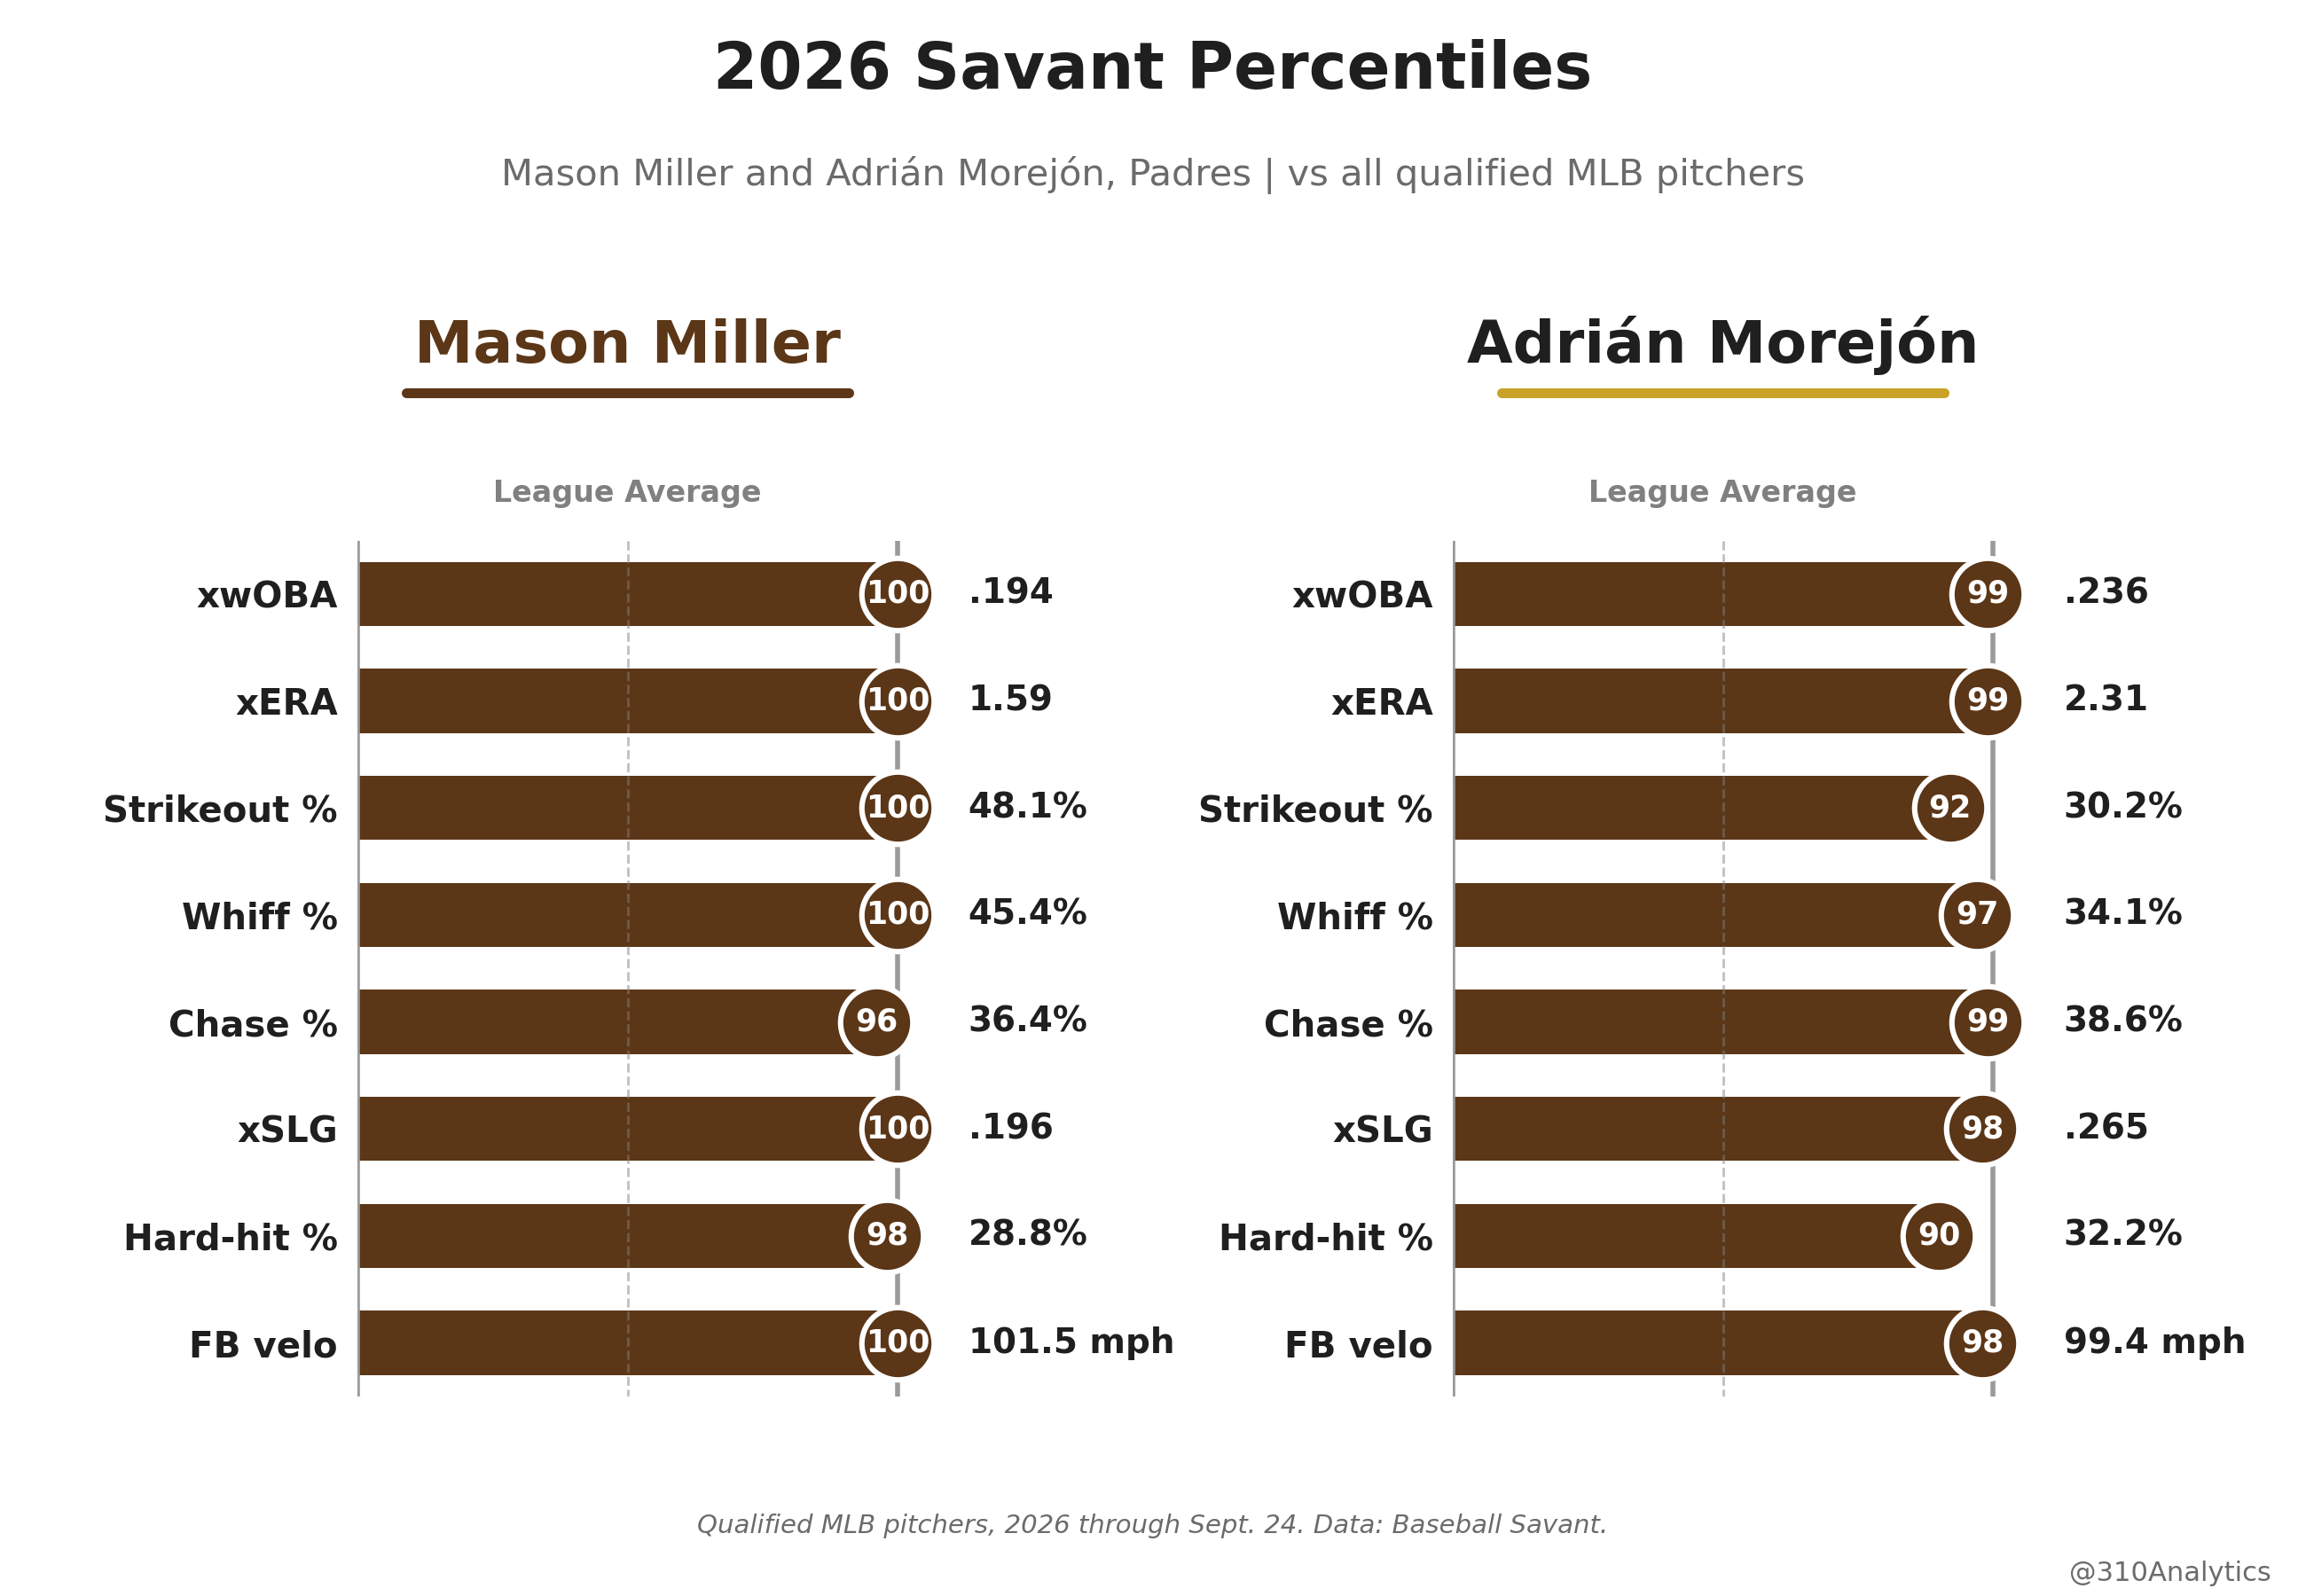

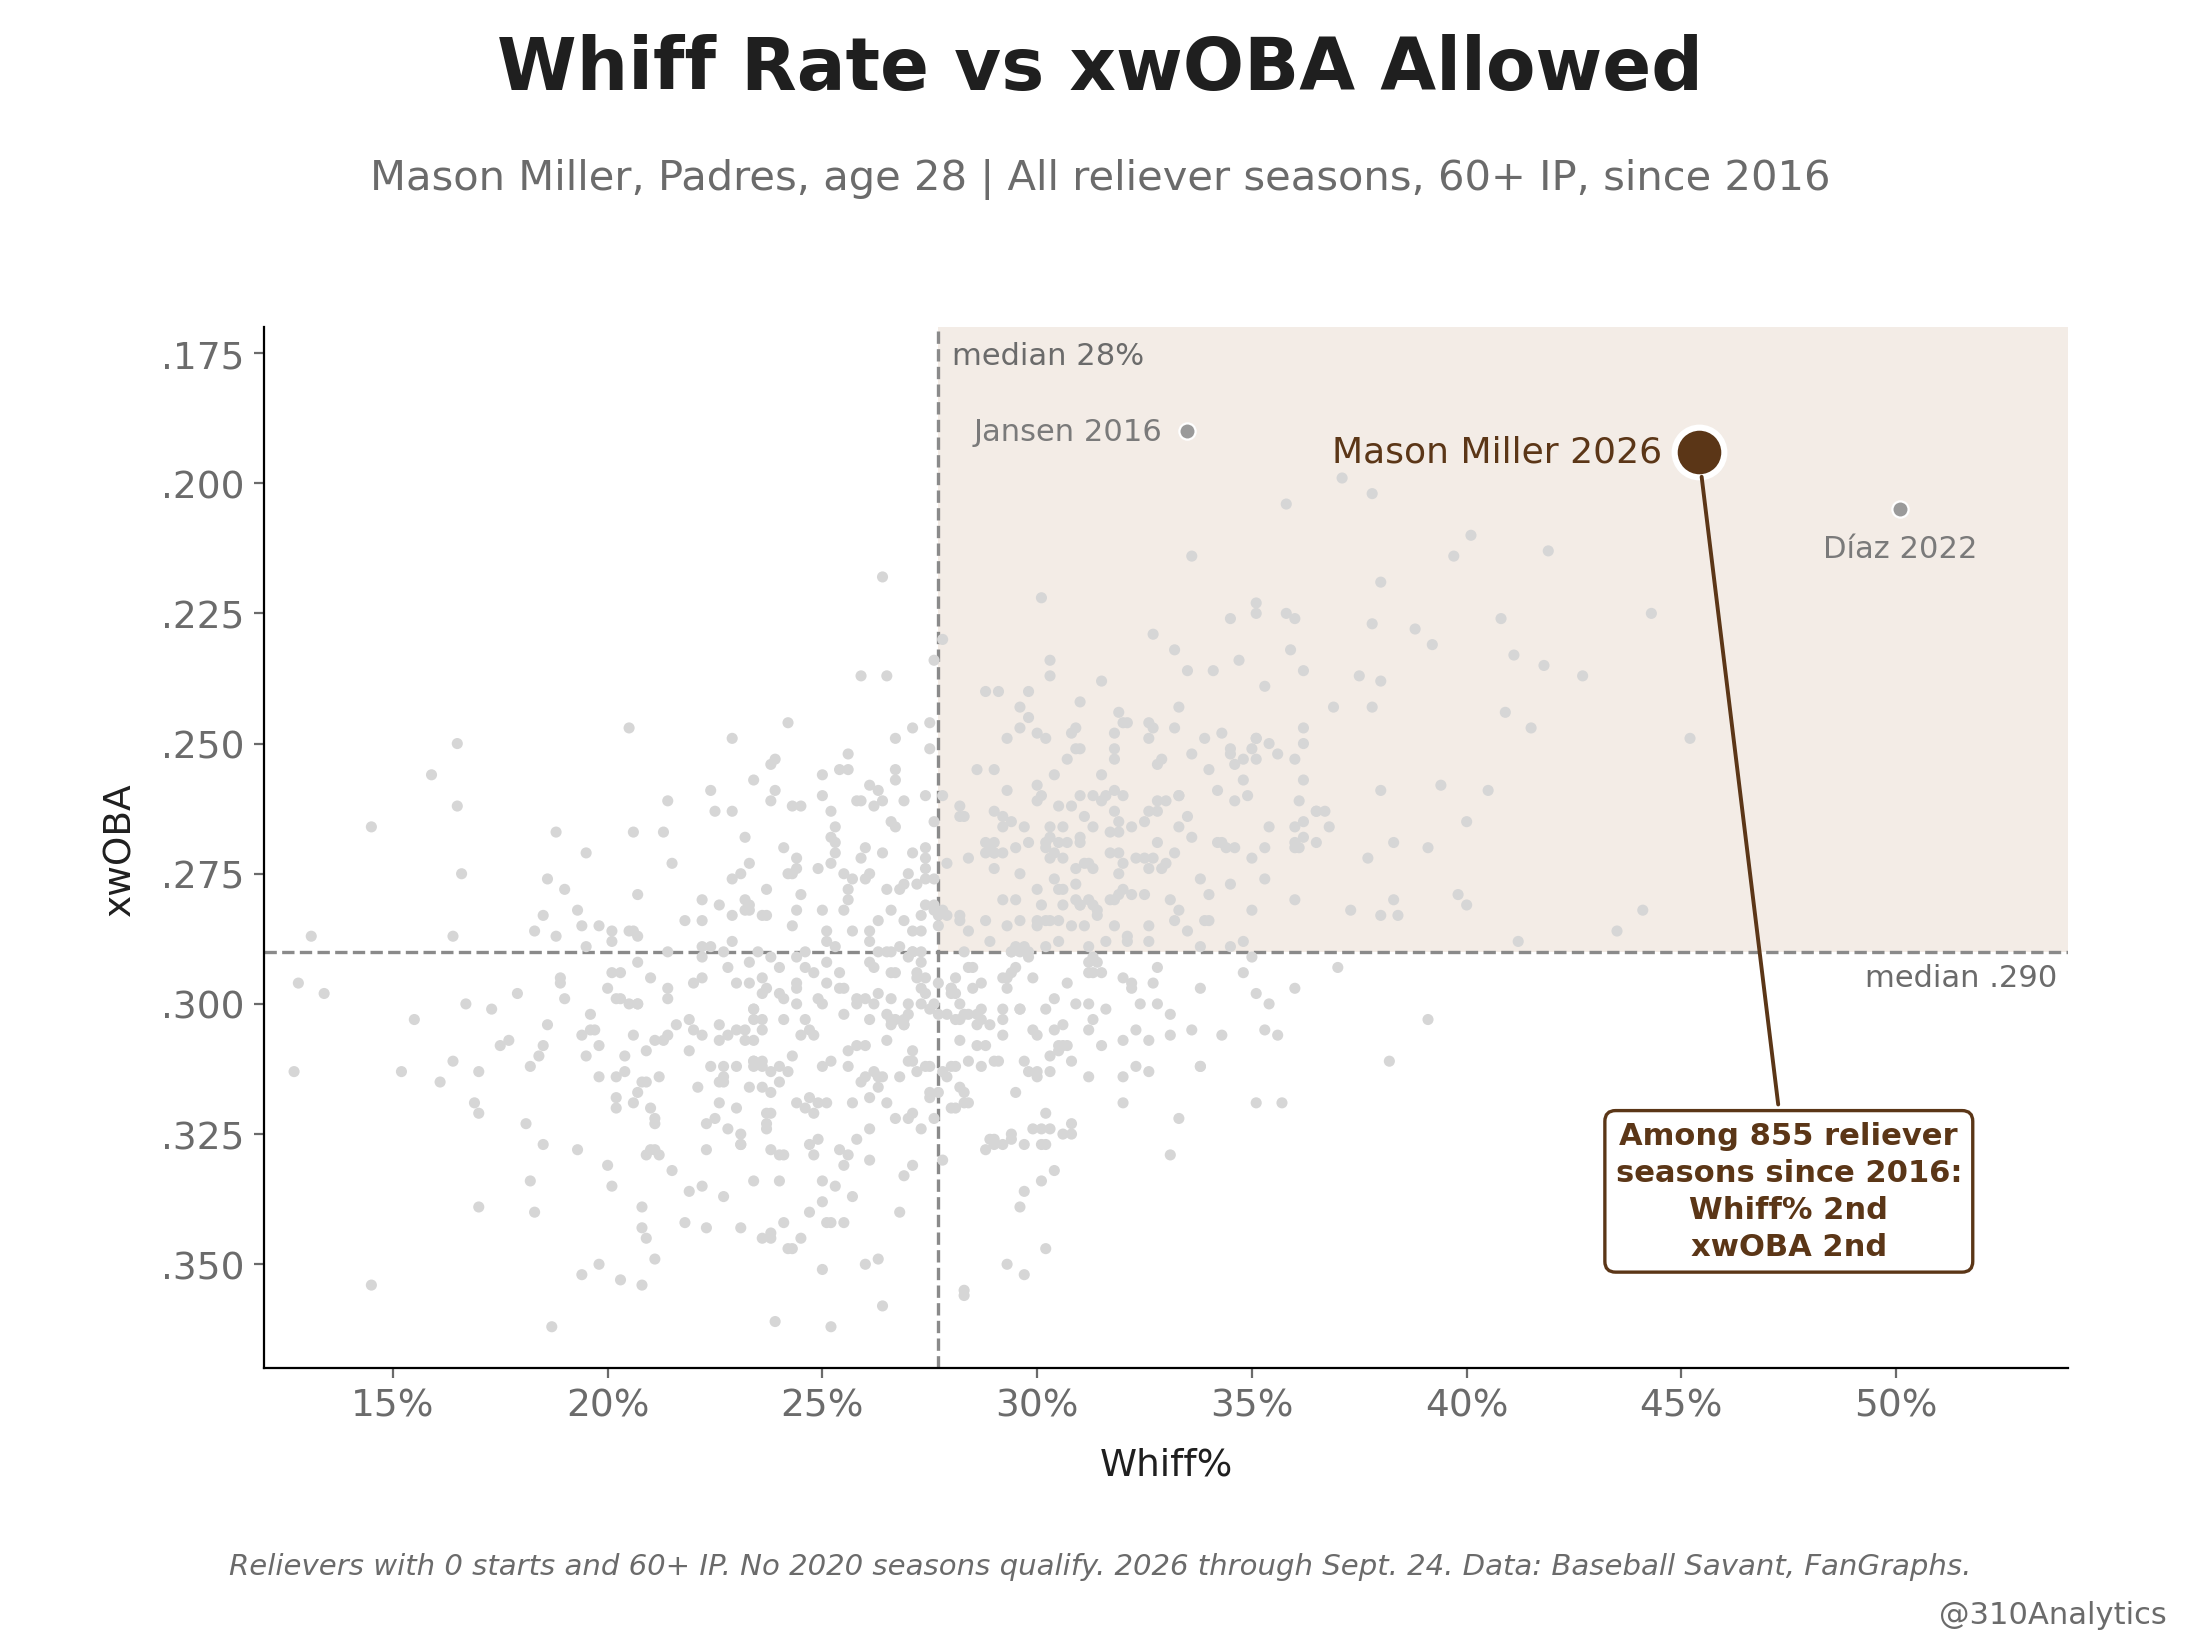

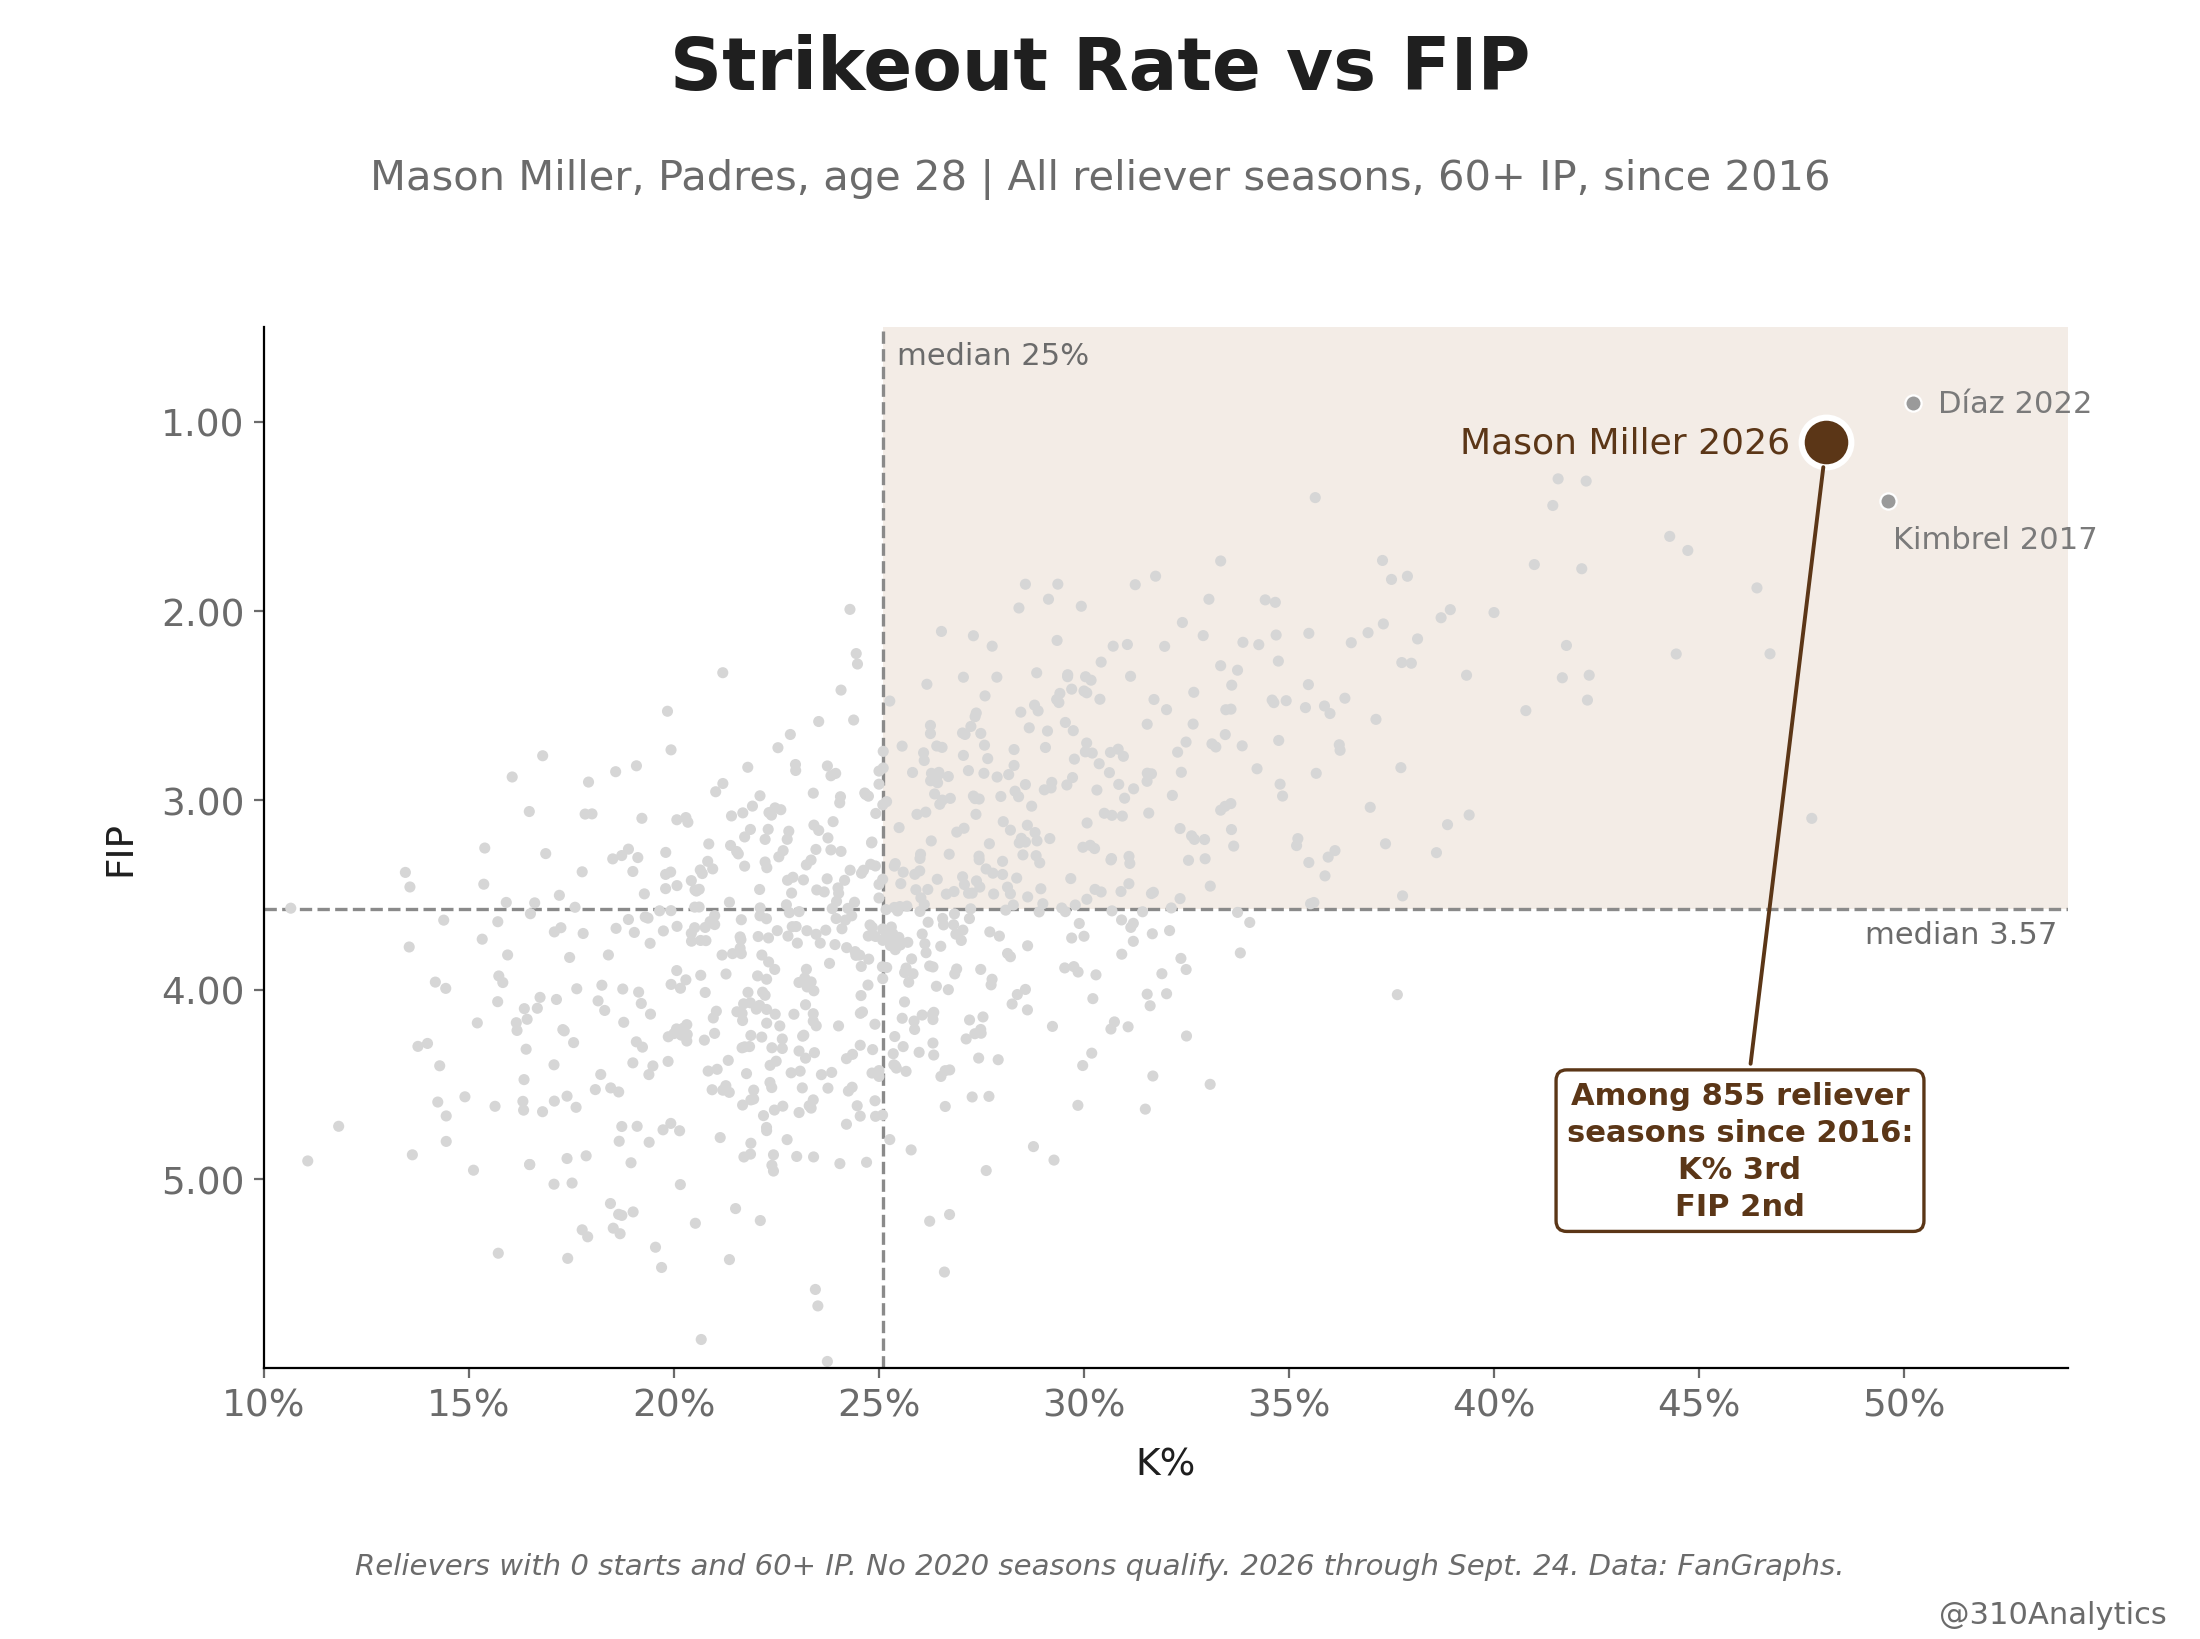

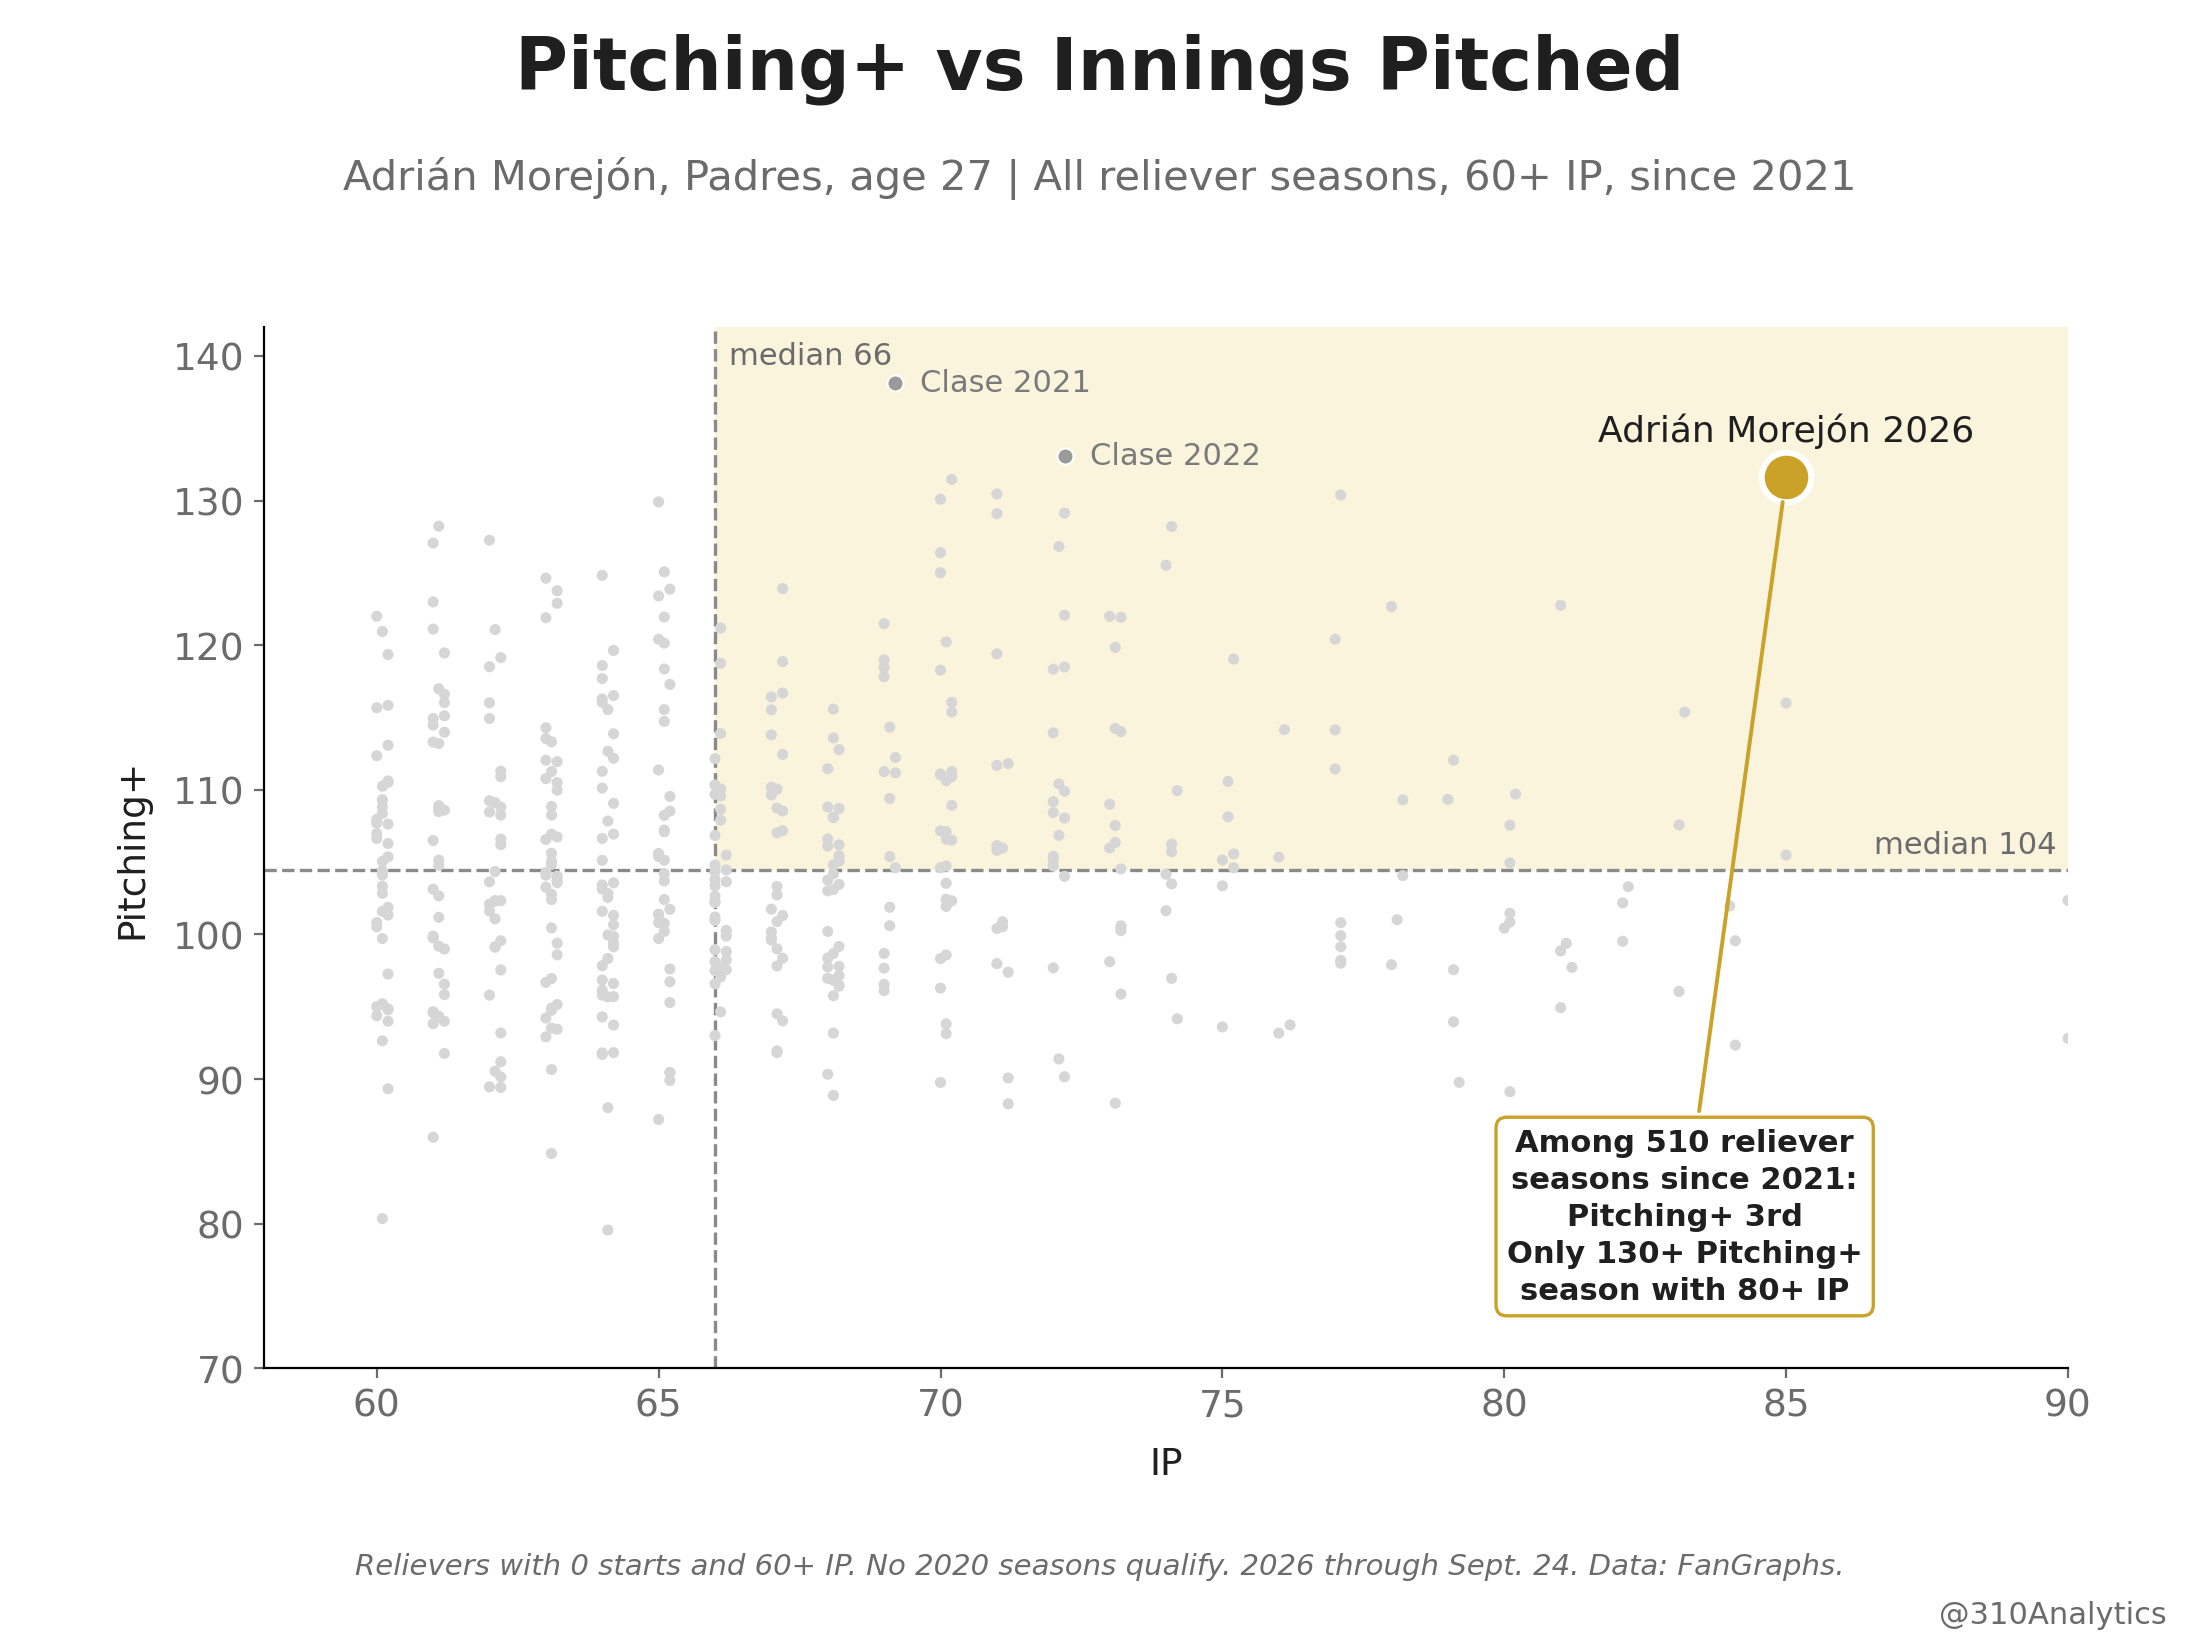

In [12]:
for n in ["miller_morejon_savant_2026", "miller_whiff_xwoba_since2016", "miller_k_fip_since2016", "morejon_pitching_ip_since2021"]:
    display(Image(filename=str(charts.FIG / f"{n}.png"), width=800))